In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict

from utility_functions import FEATURE_COLS, TRAIN_SEASONS, VAL_SEASONS, load_data, score

CURRENT_DIR = Path.cwd()
train, holdout = load_data(CURRENT_DIR)


### Kalman filter: per-team attack & defense strength

In [ ]:
@dataclass
class KFState:
    """Scalar random-walk Kalman filter state."""
    mean: float
    var: float


def _kf_predict(s: KFState, Q: float) -> KFState:
    """Time update: advance uncertainty by process noise Q."""
    return KFState(s.mean, s.var + Q)


def _kf_update(s: KFState, y: float, R: float) -> KFState:
    """Measurement update: fuse observation y with noise variance R."""
    K = s.var / (s.var + R)
    return KFState(s.mean + K * (y - s.mean), (1 - K) * s.var)

In [ ]:
def build_kalman_features(
    df: pd.DataFrame,
    Q: float = 0.15,
    R: float = 5.0,
    init_mean: float = 6.0,
    init_var: float = 9.0,
    min_matches: int = 5,
) -> pd.DataFrame:
    """
    Append kf_attack, kf_defense, opp_kf_attack, opp_kf_defense columns to df.
    No lookahead: pre-match state recorded before update step.
    Pass train+holdout together so holdout inherits terminal training states.
    """
    attack   = defaultdict(lambda: KFState(init_mean, init_var))
    defense  = defaultdict(lambda: KFState(init_mean, init_var))
    n_played = defaultdict(int)

    home_df = df[df['home'] == 1].sort_values('date').set_index('match_id')
    away_df = df[df['home'] == 0].set_index('match_id')

    records = []
    for mid, h in home_df.iterrows():
        a      = away_df.loc[mid]
        ht, at = h['team'], a['team']

        for team in (ht, at):
            attack[team]  = _kf_predict(attack[team],  Q)
            defense[team] = _kf_predict(defense[team], Q)

        def _feat(team, opp):
            if n_played[team] < min_matches or n_played[opp] < min_matches:
                return (np.nan, np.nan, np.nan, np.nan)
            return (attack[team].mean, defense[team].mean,
                    attack[opp].mean,  defense[opp].mean)

        records += [(mid, ht, *_feat(ht, at)), (mid, at, *_feat(at, ht))]

        hc = h.get('corners', np.nan)
        ac = a.get('corners', np.nan)
        if not (pd.isna(hc) or pd.isna(ac)):
            attack[ht]  = _kf_update(attack[ht],  hc, R)
            attack[at]  = _kf_update(attack[at],  ac, R)
            defense[ht] = _kf_update(defense[ht], ac, R)
            defense[at] = _kf_update(defense[at], hc, R)
            n_played[ht] += 1
            n_played[at] += 1

    feats = pd.DataFrame(
        records,
        columns=['match_id', 'team', 'kf_attack', 'kf_defense', 'opp_kf_attack', 'opp_kf_defense']
    )
    return df.merge(feats, on=['match_id', 'team'], how='left')


In [ ]:
combined = pd.concat([train, holdout], ignore_index=True)
combined = build_kalman_features(combined)

train_feats   = combined[combined['match_id'].isin(train['match_id'])].copy()
holdout_feats = combined[combined['match_id'].isin(holdout['match_id'])].copy()

nan_rate = train_feats['kf_attack'].isna().mean()
print(f'train_feats  : {train_feats.shape}')
print(f'holdout_feats: {holdout_feats.shape}')
print(f'KF NaN (cold-start): {nan_rate:.1%}  ({train_feats["kf_attack"].isna().sum():,} rows — will be dropped from training)')

train_feats  : (4180, 21)
holdout_feats: (1520, 21)
KF NaN (cold-start): 8.9%  (370 rows — will be dropped from training)


In [ ]:
KF_COLS = ['kf_attack', 'kf_defense', 'opp_kf_attack', 'opp_kf_defense']

# Post-warmup training rows only (cold-start NaN already filtered out)
train_warm = train_feats[train_feats['season'].isin(TRAIN_SEASONS)].dropna(subset=KF_COLS)

corr = (train_warm[FEATURE_COLS + ['home'] + KF_COLS + ['corners']]
        .corrwith(train_warm['corners'])
        .drop('corners')
        .sort_values(key=abs, ascending=False))
print('Correlation with corners (training, post-warmup):')
print(corr.round(4))

Correlation with corners (training, post-warmup):
feature_8         0.4110
feature_7         0.2507
kf_attack         0.2500
home              0.1640
feature_4         0.1221
kf_defense       -0.0783
feature_3         0.0701
feature_9         0.0669
feature_5        -0.0409
opp_kf_defense    0.0376
feature_1         0.0334
opp_kf_attack    -0.0173
feature_6        -0.0156
feature_10       -0.0141
feature_2         0.0045
dtype: float64


### Model evaluation with KF features

In [ ]:
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error as _mae

MODEL_COLS = FEATURE_COLS + ['home'] + KF_COLS

# Split training into core (fit) and tuning (select alpha); val never touched during tuning
CORE_SEASONS  = list(range(2012, 2018))
TUNE_SEASONS_ = [2018, 2019]

train_only = train_feats[train_feats['season'].isin(TRAIN_SEASONS)]
core_only  = train_feats[train_feats['season'].isin(CORE_SEASONS)]
tune_only  = train_feats[train_feats['season'].isin(TUNE_SEASONS_)]
val        = train_feats[train_feats['season'].isin(VAL_SEASONS)]

baseline = pd.read_csv(CURRENT_DIR / 'baseline_validation_predictions.csv')
val_b    = val.merge(baseline, on=['match_id', 'team'])

train_kf = train_only.dropna(subset=KF_COLS)
core_kf  = core_only.dropna(subset=KF_COLS)
tune_kf  = tune_only.dropna(subset=KF_COLS)

dropped_pct  = 1 - len(train_kf) / len(train_only)
val_nan_rows = val_b[KF_COLS].isna().any(axis=1).sum()
print(f'Cold-start rows dropped from training : {len(train_only) - len(train_kf):,}  ({dropped_pct:.1%})')
print(f'Validation rows with NaN KF (new teams): {val_nan_rows:,}  — imputing with training mean')

# Phase 1: alpha selection on tuning set (2018-2019)
imp_tune = SimpleImputer(strategy='mean')
X_core   = imp_tune.fit_transform(core_kf[MODEL_COLS])
X_tune   = imp_tune.transform(tune_kf[MODEL_COLS])
y_core   = core_kf['corners'].to_numpy(dtype=float)
y_tune   = tune_kf['corners'].to_numpy(dtype=float)

print('\n── Ridge alpha sweep on tuning set (2018–2019) ─────────')
ridge_tune = {}
for a in [1.0, 5.0, 10.0, 50.0, 100.0]:
    preds = Ridge(alpha=a).fit(X_core, y_core).predict(X_tune)
    score(f'  α={a}', y_tune, preds)
    ridge_tune[a] = _mae(y_tune, preds)

print('\n── Poisson alpha sweep on tuning set (2018–2019) ───────')
poisson_tune = {}
for a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    preds = PoissonRegressor(alpha=a, max_iter=500).fit(X_core, y_core).predict(X_tune)
    score(f'  α={a}', y_tune, preds)
    poisson_tune[a] = _mae(y_tune, preds)

best_ridge_a   = min(ridge_tune,   key=ridge_tune.get)
best_poisson_a = min(poisson_tune, key=poisson_tune.get)
print(f'\nTuning-selected: Ridge α={best_ridge_a},  Poisson α={best_poisson_a}')

# Phase 2: refit on full training set (2012-2019), report on val for the first time
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(train_kf[MODEL_COLS])
X_val   = imputer.transform(val_b[MODEL_COLS])
y_train = train_kf['corners'].to_numpy(dtype=float)
y_val   = val_b['corners'].to_numpy(dtype=float)
yhat    = val_b['baseline_predicted_corners'].to_numpy(dtype=float)

ridge = Ridge(alpha=best_ridge_a).fit(X_train, y_train)
pg    = PoissonRegressor(alpha=best_poisson_a, max_iter=500).fit(X_train, y_train)

print('\n── Final comparison on val (2020–2022) ─────────────────')
score('Baseline',     y_val, yhat)
score('Ridge  + KF',  y_val, ridge.predict(X_val))
score('Poisson + KF', y_val, pg.predict(X_val))

Cold-start rows dropped from training : 330  (10.9%)
Validation rows with NaN KF (new teams): 40  — imputing with training mean

── Ridge alpha sweep on tuning set (2018–2019) ─────────
  α=1.0                         MAE=2.1628  RMSE=2.7233  PoissonDev=1.4133
  α=5.0                         MAE=2.1553  RMSE=2.7084  PoissonDev=1.3936
  α=10.0                        MAE=2.1507  RMSE=2.6969  PoissonDev=1.3788
  α=50.0                        MAE=2.1644  RMSE=2.7053  PoissonDev=1.3802
  α=100.0                       MAE=2.1994  RMSE=2.7513  PoissonDev=1.4218

── Poisson alpha sweep on tuning set (2018–2019) ───────
  α=0.1                         MAE=2.1459  RMSE=2.6814  PoissonDev=1.3627
  α=0.5                         MAE=2.2260  RMSE=2.7941  PoissonDev=1.4650
  α=1.0                         MAE=2.2651  RMSE=2.8534  PoissonDev=1.5204
  α=2.0                         MAE=2.2938  RMSE=2.8981  PoissonDev=1.5636
  α=5.0                         MAE=2.3189  RMSE=2.9378  PoissonDev=1.6033

Tunin

### Diagnostics: collinearity · coefficients · ablation

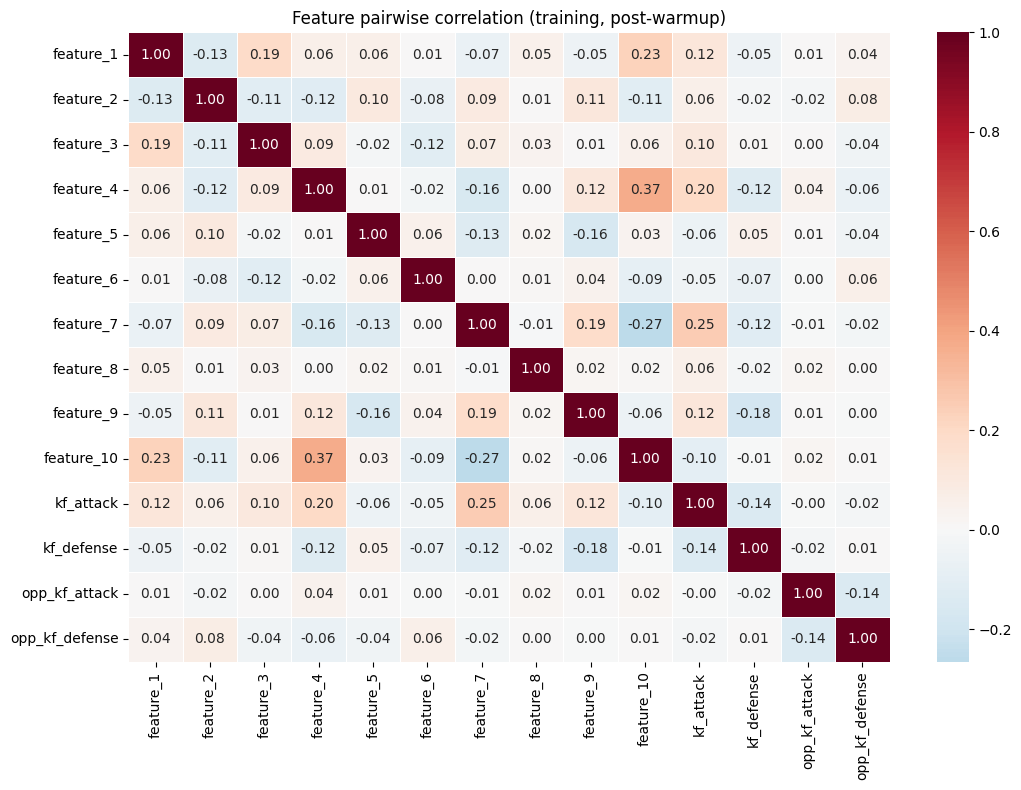


KF features vs all features (r):
                feature_1  feature_2  feature_3  feature_4  feature_5  \
kf_attack           0.125      0.057      0.102      0.196     -0.059   
kf_defense         -0.051     -0.018      0.014     -0.125      0.054   
opp_kf_attack       0.008     -0.021      0.002      0.045      0.007   
opp_kf_defense      0.038      0.079     -0.042     -0.064     -0.043   

                feature_6  feature_7  feature_8  feature_9  feature_10  
kf_attack          -0.048      0.253      0.062      0.125      -0.098  
kf_defense         -0.069     -0.121     -0.022     -0.177      -0.007  
opp_kf_attack       0.000     -0.006      0.021      0.008       0.023  
opp_kf_defense      0.065     -0.024      0.004      0.001       0.008  


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairwise correlation among all features — focus on KF rows vs feature_* cols
cols = FEATURE_COLS + KF_COLS
cm   = train_warm[cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', linewidths=0.4, ax=ax)
ax.set_title('Feature pairwise correlation (training, post-warmup)')
plt.tight_layout()
plt.show()

# Also print the KF rows only for easy reading
print('\nKF features vs all features (r):')
print(cm.loc[KF_COLS, FEATURE_COLS].round(3))

In [ ]:
# Ridge coefficients — which features actually get used
coef = pd.Series(ridge.coef_, index=MODEL_COLS).sort_values(key=abs, ascending=False)
print(f'Ridge coefficients (α={best_ridge_a}, sorted by |coef|):')
print(coef.round(4))

Ridge coefficients (α=10.0, sorted by |coef|):
feature_8         7.1183
feature_7         3.5991
feature_4         1.6163
home              0.7252
feature_3         0.3846
feature_2        -0.3570
kf_attack         0.2880
feature_6        -0.2273
feature_1        -0.2208
feature_9        -0.2072
opp_kf_defense    0.1017
feature_10        0.0837
feature_5        -0.0439
kf_defense        0.0174
opp_kf_attack     0.0056
dtype: float64


In [ ]:
# Ablation: marginal contribution of each KF group
# Uses tuning-selected alpha — val not involved
ablation_groups = [
    ('no KF',          []),
    ('+ kf_attack',    ['kf_attack']),
    ('+ kf_atk + def', ['kf_attack', 'kf_defense']),
    ('+ all KF',       KF_COLS),
]

print(f'Ablation (Ridge α={best_ridge_a}, tuning-selected):')
_imp = SimpleImputer(strategy='mean')
for label, extra in ablation_groups:
    cols  = FEATURE_COLS + ['home'] + extra
    X_tr  = _imp.fit_transform(train_kf[cols])
    X_v   = _imp.transform(val_b[cols])
    preds = Ridge(alpha=best_ridge_a).fit(X_tr, y_train).predict(X_v)
    score(label, y_val, preds)

Ablation (Ridge α=10.0, tuning-selected):
no KF                           MAE=2.2074  RMSE=2.7738  PoissonDev=1.2937
+ kf_attack                     MAE=2.2014  RMSE=2.7606  PoissonDev=1.2827
+ kf_atk + def                  MAE=2.2015  RMSE=2.7602  PoissonDev=1.2821
+ all KF                        MAE=2.2107  RMSE=2.7668  PoissonDev=1.2865


### kf_attack only — alpha sweep

In [ ]:
SLIM_COLS = FEATURE_COLS + ['home', 'kf_attack']

# Phase 1: alpha selection on tuning set
imp_slim_tune = SimpleImputer(strategy='mean')
X_core_s = imp_slim_tune.fit_transform(core_kf[SLIM_COLS])
X_tune_s = imp_slim_tune.transform(tune_kf[SLIM_COLS])

print('── Ridge alpha sweep on tuning set (kf_attack only) ────')
slim_ridge_tune = {}
for a in [1.0, 5.0, 10.0, 50.0, 100.0]:
    preds = Ridge(alpha=a).fit(X_core_s, y_core).predict(X_tune_s)
    score(f'  α={a}', y_tune, preds)
    slim_ridge_tune[a] = _mae(y_tune, preds)

print('\n── Poisson alpha sweep on tuning set (kf_attack only) ──')
slim_poisson_tune = {}
for a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    preds = PoissonRegressor(alpha=a, max_iter=500).fit(X_core_s, y_core).predict(X_tune_s)
    score(f'  α={a}', y_tune, preds)
    slim_poisson_tune[a] = _mae(y_tune, preds)

best_slim_ridge_a   = min(slim_ridge_tune,   key=slim_ridge_tune.get)
best_slim_poisson_a = min(slim_poisson_tune, key=slim_poisson_tune.get)
print(f'\nTuning-selected: Ridge α={best_slim_ridge_a},  Poisson α={best_slim_poisson_a}')

# Phase 2: refit on full training set
imp_slim = SimpleImputer(strategy='mean')
X_tr_s   = imp_slim.fit_transform(train_kf[SLIM_COLS])
X_val_s  = imp_slim.transform(val_b[SLIM_COLS])

ridge_slim = Ridge(alpha=best_slim_ridge_a).fit(X_tr_s, y_train)
pg_slim    = PoissonRegressor(alpha=best_slim_poisson_a, max_iter=500).fit(X_tr_s, y_train)

print('\n── Final comparison on val (2020–2022) ─────────────────')
score('Baseline',                    y_val, yhat)
score('Ridge  + all KF',             y_val, ridge.predict(X_val))
score('Poisson + all KF',            y_val, pg.predict(X_val))
score('Ridge  + kf_attack only',     y_val, ridge_slim.predict(X_val_s))
score('Poisson + kf_attack only',    y_val, pg_slim.predict(X_val_s))

── Ridge alpha sweep on tuning set (kf_attack only) ────
  α=1.0                         MAE=2.1688  RMSE=2.7281  PoissonDev=1.4157
  α=5.0                         MAE=2.1605  RMSE=2.7128  PoissonDev=1.3962
  α=10.0                        MAE=2.1554  RMSE=2.7008  PoissonDev=1.3815
  α=50.0                        MAE=2.1668  RMSE=2.7076  PoissonDev=1.3824
  α=100.0                       MAE=2.2010  RMSE=2.7534  PoissonDev=1.4240
  α=200.0                       MAE=2.2393  RMSE=2.8146  PoissonDev=1.4811

── Poisson alpha sweep on tuning set (kf_attack only) ──
  α=0.1                         MAE=2.1485  RMSE=2.6838  PoissonDev=1.3650
  α=0.5                         MAE=2.2270  RMSE=2.7971  PoissonDev=1.4678
  α=1.0                         MAE=2.2662  RMSE=2.8577  PoissonDev=1.5245
  α=2.0                         MAE=2.2947  RMSE=2.9037  PoissonDev=1.5691
  α=5.0                         MAE=2.3190  RMSE=2.9444  PoissonDev=1.6099

Tuning-selected: Ridge α=10.0,  Poisson α=0.1

── Final com

### KF hyperparameter search: Q and R

In [ ]:
from sklearn.metrics import mean_poisson_deviance

Q_GRID = [0.03, 0.05, 0.10, 0.15, 0.30, 0.50, 1.00, 2.00]
R_GRID = [3.0, 5.0, 8.0, 11.0, 15.0, 20.0, 30.0]

def _composite(y_true, y_pred):
    """Tuning objective: 0.25·MAE + 0.25·RMSE + 0.50·PoissonDev."""
    y_pos = np.clip(y_pred, 1e-6, None)
    return (0.25 * _mae(y_true, y_pred)
          + 0.25 * np.sqrt(((y_true - y_pred) ** 2).mean())
          + 0.50 * mean_poisson_deviance(y_true, y_pos))

# Search on core (2012–2017) → tune (2018–2019); val never touched
results = []
for Q in Q_GRID:
    for R in R_GRID:
        ct  = build_kalman_features(train, Q=Q, R=R)
        c_  = ct[ct['season'].isin(CORE_SEASONS)].dropna(subset=['kf_attack'])
        t_  = ct[ct['season'].isin(TUNE_SEASONS_)].dropna(subset=['kf_attack'])

        imp_ = SimpleImputer(strategy='mean')
        pred = (PoissonRegressor(alpha=0.1, max_iter=500)
                .fit(imp_.fit_transform(c_[SLIM_COLS]), c_['corners'].to_numpy(float))
                .predict(imp_.transform(t_[SLIM_COLS])))

        yt = t_['corners'].to_numpy(float)
        results.append({'Q': Q, 'R': R,
                        'composite': _composite(yt, pred),
                        'MAE': _mae(yt, pred)})

res_df   = pd.DataFrame(results).sort_values('composite').reset_index(drop=True)
best_Q   = res_df.loc[0, 'Q']
best_R   = res_df.loc[0, 'R']

print('Top 10 (Q, R) combinations on tuning set:')
print(res_df.head(10).round(4).to_string(index=False))
print(f'\nBest: Q={best_Q}, R={best_R}  composite={res_df.loc[0,"composite"]:.4f}')

In [ ]:
# Rebuild full pipeline with best Q, R; evaluate on val for the first time
combined_best = pd.concat([train, holdout], ignore_index=True)
combined_best = build_kalman_features(combined_best, Q=best_Q, R=best_R)

train_best   = combined_best[combined_best['match_id'].isin(train['match_id'])].copy()
train_kf_b   = train_best[train_best['season'].isin(TRAIN_SEASONS)].dropna(subset=['kf_attack'])
val_b_best   = (train_best[train_best['season'].isin(VAL_SEASONS)]
                .merge(baseline, on=['match_id', 'team']))

imp_b  = SimpleImputer(strategy='mean')
X_tr_b = imp_b.fit_transform(train_kf_b[SLIM_COLS])
X_va_b = imp_b.transform(val_b_best[SLIM_COLS])
y_tr_b = train_kf_b['corners'].to_numpy(float)
y_va_b = val_b_best['corners'].to_numpy(float)
yhat_b = val_b_best['baseline_predicted_corners'].to_numpy(float)

pg_best = PoissonRegressor(alpha=0.1, max_iter=500).fit(X_tr_b, y_tr_b)

print(f'KF params: Q={best_Q}, R={best_R}')
print()
score('Baseline',                          y_va_b, yhat_b)
score('Poisson + kf_atk (Q=0.15, R=5.0)', y_val,  pg_slim.predict(X_val_s))
score(f'Poisson + kf_atk (Q={best_Q}, R={best_R})', y_va_b, pg_best.predict(X_va_b))